In [2]:
import pytesseract
from pdf2image import convert_from_path
import cv2
from matplotlib import pyplot as plt
import numpy as np
import pytesseract
from PIL import Image

In [3]:
# Path to the uploaded PDF
pdf_path = 'D:\Ritik\data_science\Pdf_text\CBT4(Final).pdf'

# Convert PDF to images
images = convert_from_path(pdf_path)

# # Perform OCR on each page and store the text
# ocr_text = ""
# for page_num, image in enumerate(images):
#     ocr_text += f"--- Page {page_num + 1} ---\n"
#     ocr_text += pytesseract.image_to_string(image)

# # Save the extracted text to a file for review
# output_text_path = 'CBT4_OCR_Extracted_Text.txt'
# with open(output_text_path, 'w') as text_file:
#     text_file.write(ocr_text)

# output_text_path


<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\Mobcoder ID-090\AppData\Local\Temp\ipykernel_4444\404026030.py:2: SyntaxWarning: invalid escape sequence '\R'
  pdf_path = 'D:\Ritik\data_science\Pdf_text\CBT4(Final).pdf'


In [4]:
# Extract text specifically from page 2
img = images[1]  # Page indexing starts at 0

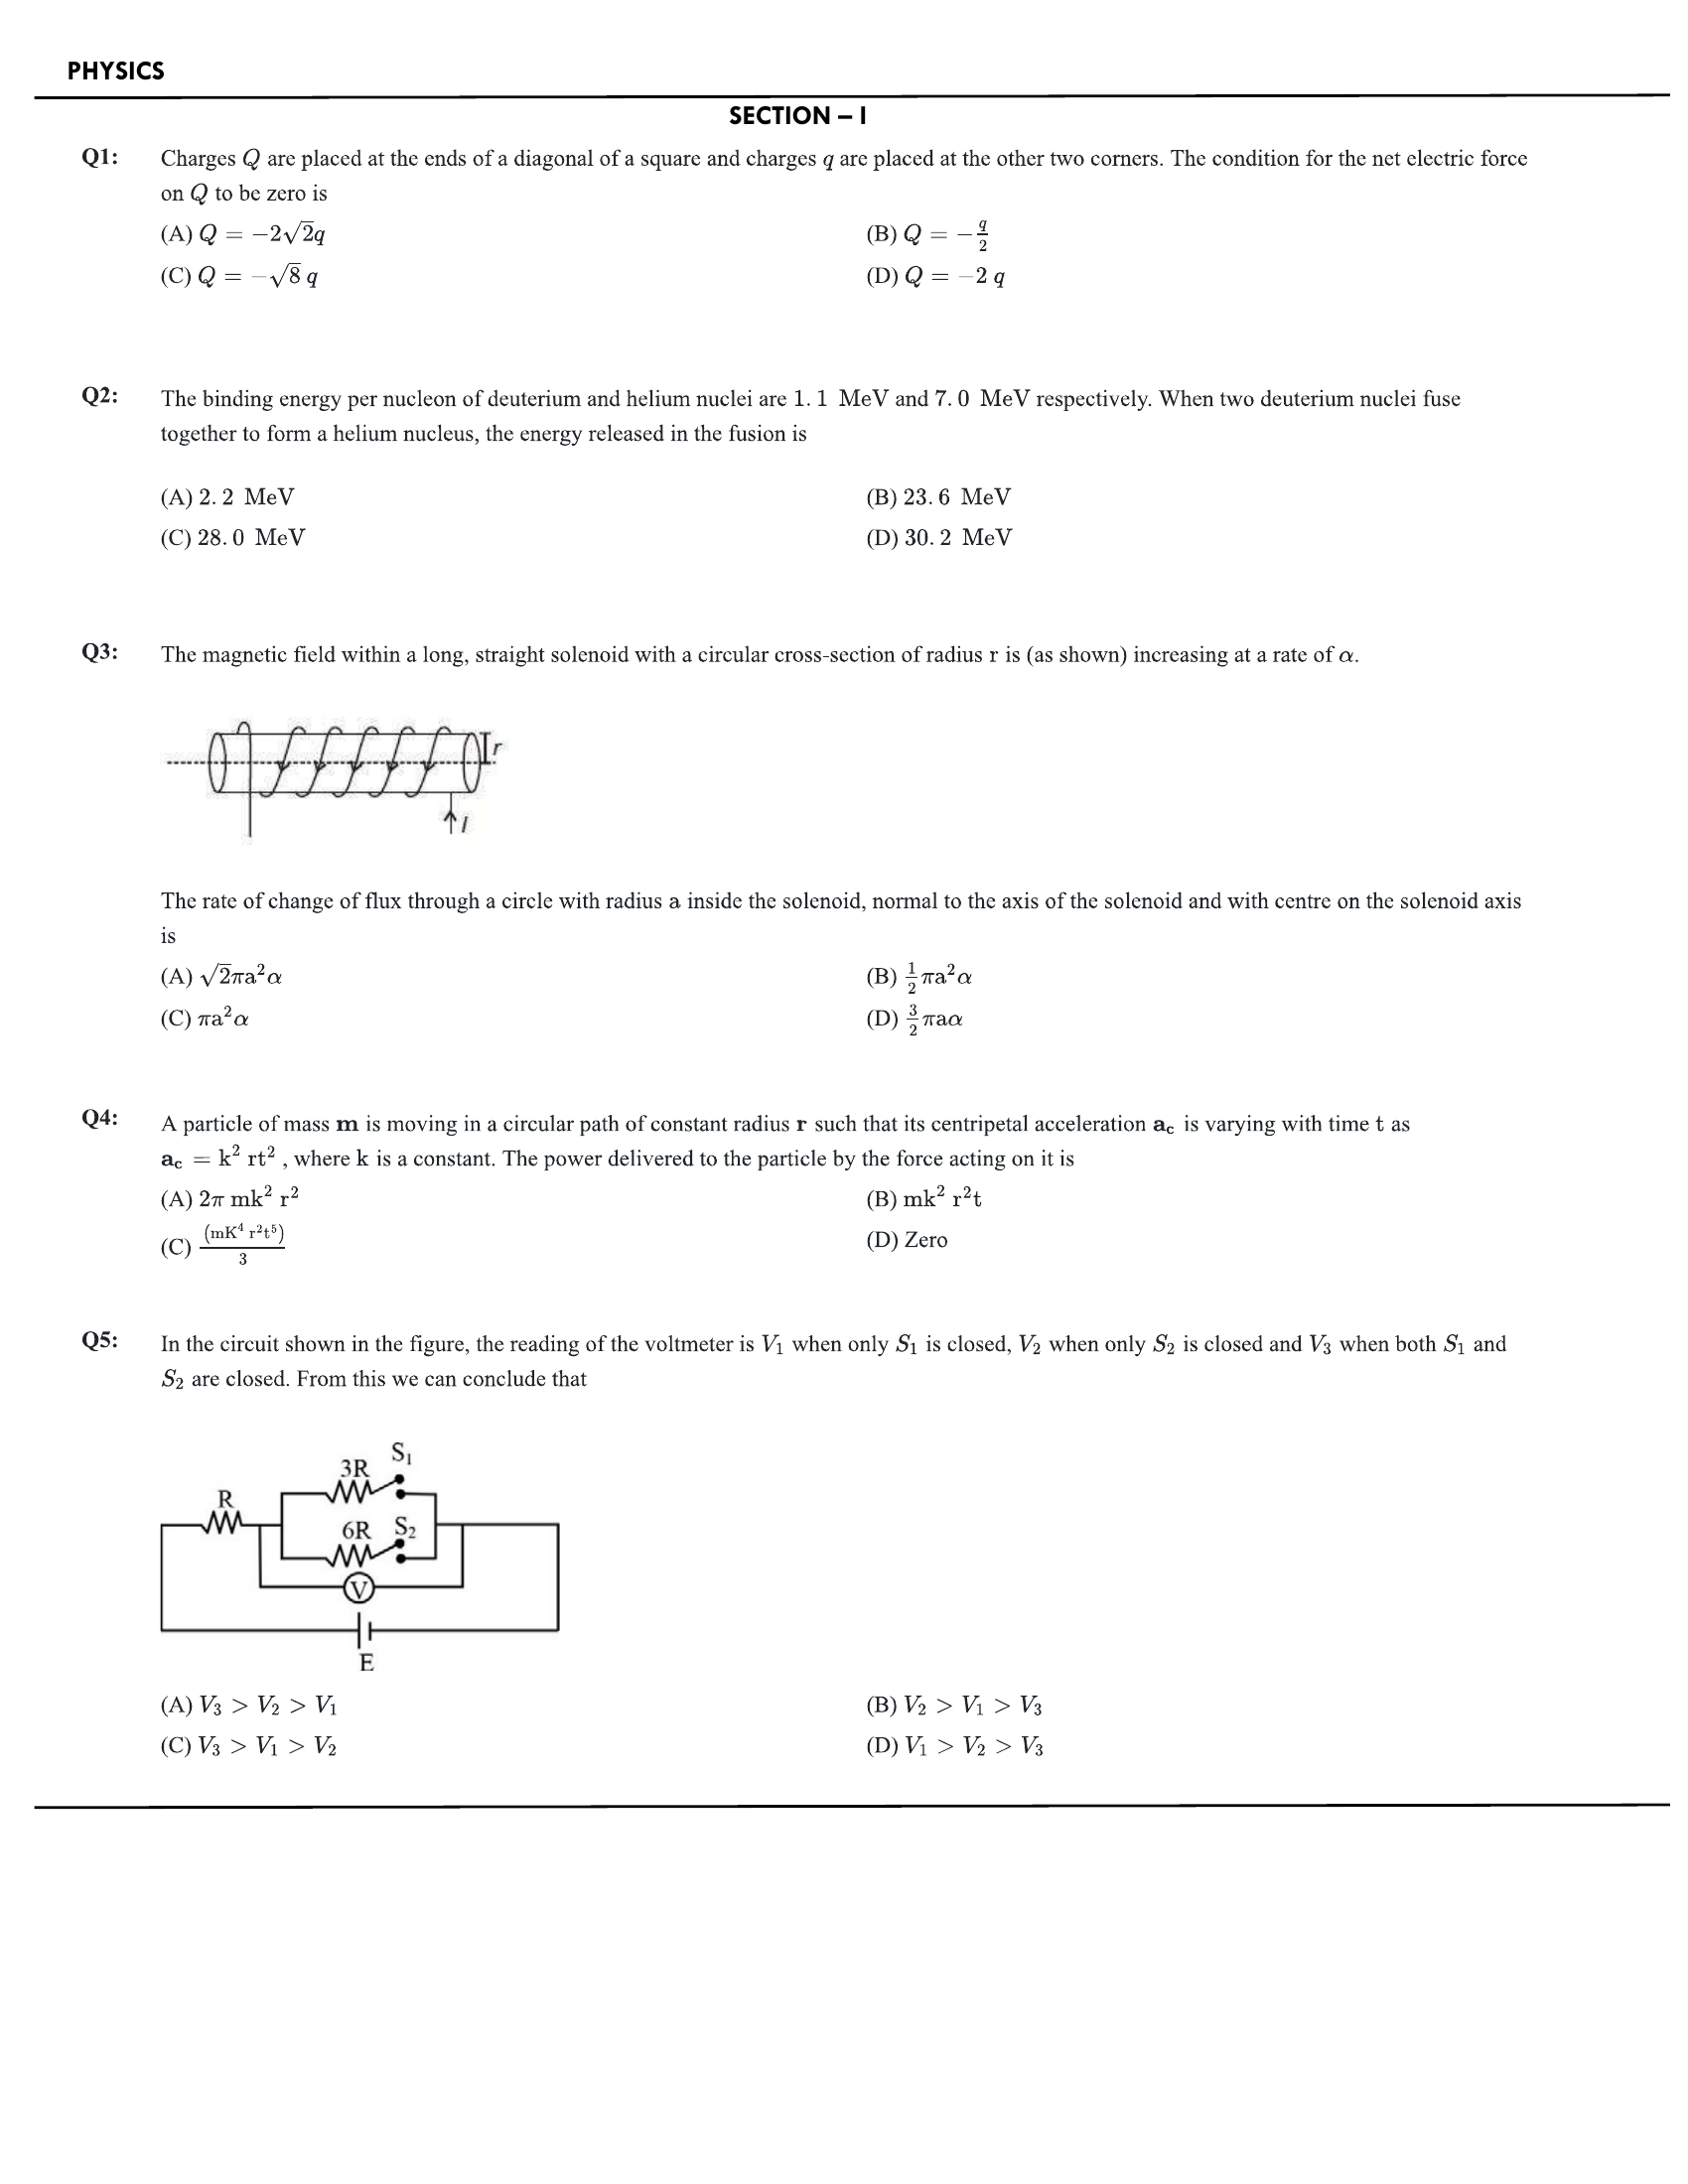

In [5]:
display(img)

(np.float64(-0.5), np.float64(1699.5), np.float64(2199.5), np.float64(-0.5))

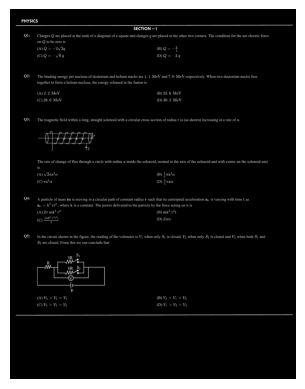

In [6]:
img = np.array(img)
# Invert the image
inverted_image = cv2.bitwise_not(img)
plt.imshow(inverted_image)
plt.axis('off')  

In [7]:
def grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [8]:
gray_image = grayscale(img)
cv2.imwrite("pdf_output/gray_scale_img.jpg", gray_image)
display("pdf_output/gray_scale_img.jpg")


'pdf_output/gray_scale_img.jpg'

In [9]:
thresh, im_bw = cv2.threshold(gray_image, 210, 230, cv2.THRESH_BINARY)
cv2.imwrite("pdf_output/bw_image.jpg", im_bw)
display("pdf_output/bw_image.jpg")

'pdf_output/bw_image.jpg'

In [10]:
def noise_removal(image):
    kernal = np.ones((1,1), np.uint8)
    image = cv2.dilate(image, kernal, iterations =1)
    kernal = np.ones((1,1), np.uint8)
    image = cv2.erode(image, kernal, iterations=1)
    image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernal)
    image = cv2.medianBlur(image, 3)
    return image
no_noise = noise_removal(im_bw)
cv2.imwrite('pdf_output/no_noise.jpg', no_noise)
display('pdf_output/no_noise.jpg')

'pdf_output/no_noise.jpg'

In [11]:
def thick_font(image):
    image = cv2.bitwise_not(image)
    kernel = np.ones((2,2),np.uint8)
    image = cv2.dilate(image, kernel, iterations=1)
    image = cv2.bitwise_not(image)
    return (image)

In [12]:
dialated_images = thick_font(no_noise)
cv2.imwrite('pdf_output/dialated_img.jpg', dialated_images)

True

In [13]:
orc_result = pytesseract.image_to_string(dialated_images)

'PHYSICS\n\nQi:\n\nQ2:\n\nQ3:\n\nQs:\n\nSECTION -1\n\nCharges Q are placed at the ends of a diagonal of a square and charges q are placed at the other two comers. The condition for the net electric force\non Q to be zero is\n\n(AQ- 2v2¢ (B)Q- ¢\n(Q  v8¢ MQ 2\n\nThe binding energy per nucleon of deuterium and helium nuclei are 1.1 MeV and 7.0 MeV respectively When two deutenum nuclei fuse\ntogether to form a helium nucleus, the energy released in the fusion is\n\n(A) 2.2 MeV (B) 23.6 MeV\n(C) 28.0 MeV (D) 30.2 MeV\n\nThe magnetic field within a long, straight solenoid with a circular cross section of radius r is {as shown) increasing at a rate of a.\n\nThe rate of change of flux through a circle with radius a inside the solenoid, normal to the axis of the solenoid and with centre on the solenoid axis\nis\n(A) V2za?a (B) ; naa\n\n{C) maa {D) jman\n\nA particle of mass m is moving in a circular path of constant radius r such that its centripetal acceleration a, is varying with time t as\n

In [26]:
with open("pdf_output/output.txt", "w") as text_file:
    text_file.write(orc_result)

## For Image Extract 

In [32]:
import pymupdf
from pypdf import PdfReader

In [27]:
doc = pymupdf.open("CBT4(Final).pdf")
for page in doc:
    text = page.get_text()
    with open(f"pdf_output/extracted_image_pymupdf/result_page_{page.number}.txt", "w") as f:
            f.write(text)

    for image_index, img in enumerate(page.get_images(), start=1):
        xref = img[0]
        base_image = doc.extract_image(xref)
        image_bytes = base_image["image"]
        image_ext = base_image["ext"]
        with open(f"pdf_output/extracted_image_pymupdf/image{page.number+1}_{image_index}.{image_ext}", "wb") as image:
            image.write(image_bytes)

In [34]:
def extract_text_image(pdf):
    page_no = 1
    for page in pdf.pages:
        text = page.extract_text()
        with open(f"pdf_output/extracted_image_pypdf/result_page_{page_no}.txt", "w") as f:
            for word in text:
                f.write(word)
        page_no += 1
        
        try:
            for count, image_file_object in enumerate(page.images):
                with open(f"pdf_output/extracted_image_pypdf/{str(count) + image_file_object.name}", "wb") as fp:
                    fp.write(image_file_object.data)
        except Exception:
            continue

reader = PdfReader("CBT4(Final).pdf")
extract_text_image(reader)